Dataset Shape: (123117, 85)
   no  id.orig_p  id.resp_p proto service  flow_duration  fwd_pkts_tot  \
0   0      38667       1883   tcp    mqtt      32.011598             9   
1   1      51143       1883   tcp    mqtt      31.883584             9   
2   2      44761       1883   tcp    mqtt      32.124053             9   
3   3      60893       1883   tcp    mqtt      31.961063             9   
4   4      51087       1883   tcp    mqtt      31.902362             9   

   bwd_pkts_tot  fwd_data_pkts_tot  bwd_data_pkts_tot  ...  active.std  \
0             5                  3                  3  ...         0.0   
1             5                  3                  3  ...         0.0   
2             5                  3                  3  ...         0.0   
3             5                  3                  3  ...         0.0   
4             5                  3                  3  ...         0.0   

       idle.min      idle.max      idle.tot      idle.avg  idle.std  \
0  2.972918

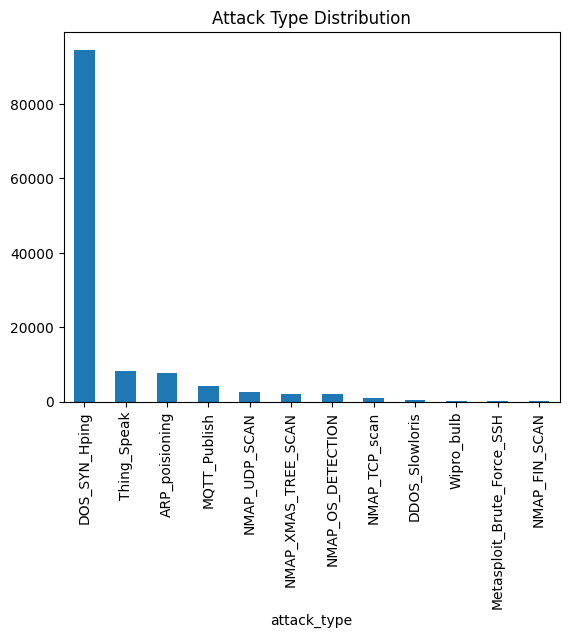


Protocol vs Attack:
 proto                       icmp    tcp   udp
attack_type                                  
ARP_poisioning                 8   1927  5815
DDOS_Slowloris                 0    529     5
DOS_SYN_Hping                  0  94659     0
MQTT_Publish                   0   4146     0
Metasploit_Brute_Force_SSH     0     29     8
NMAP_FIN_SCAN                  0     25     3
NMAP_OS_DETECTION              0   2000     0
NMAP_TCP_scan                  0   1002     0
NMAP_UDP_SCAN                  2    142  2446
NMAP_XMAS_TREE_SCAN            0   2007     3
Thing_Speak                   45   3779  4284
Wipro_bulb                     2    182    69

Service vs Attack:
 service                         -  dhcp   dns  http  irc  mqtt  ntp  radius  \
attack_type                                                                   
ARP_poisioning                546    26  5583   129    0     0    7       0   
DDOS_Slowloris                  6     2     3   523    0     0    0       0 

/tmp/ipykernel_1030/1296047865.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  flow_stats = df.groupby('attack_type')['flow_duration'].agg(['mean','std'])


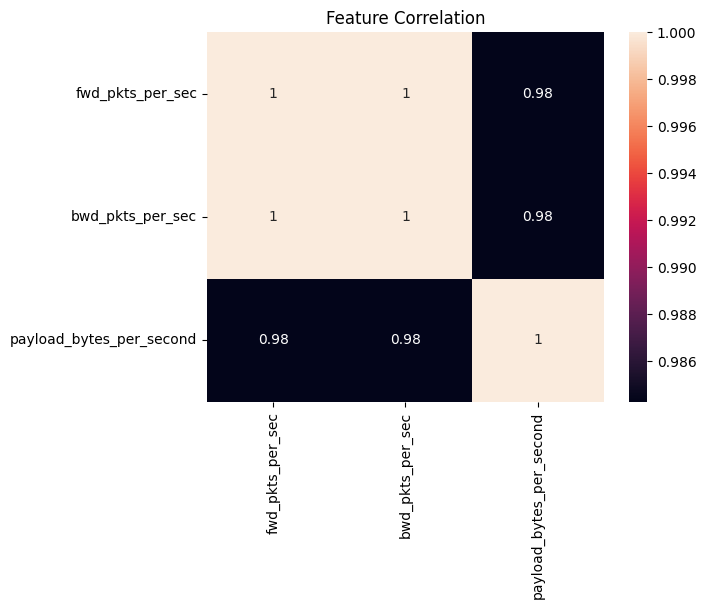

/tmp/ipykernel_1030/1296047865.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_features = df.groupby('attack_type')[['fwd_iat_avg','bwd_iat_avg']].mean()


KeyError: "Columns not found: 'fwd_iat_avg', 'bwd_iat_avg'"

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("RT_IOT2022.csv")

print("Dataset Shape:", df.shape)
print(df.head())
print(df.info())


# TRANSFORM


df = df.dropna()
# I remove rows with missing values to avoid errors and inconsistencies


df.columns = df.columns.str.lower()
# This is standardize column names to lowercase for easier access

df['attack_type'] = df['attack_type'].astype('category')
df['proto'] = df['proto'].astype('category')
df['service'] = df['service'].astype('category')


# LOAD

print("Cleaned Dataset Shape:", df.shape)



# Attack distribution
attack_counts = df['attack_type'].value_counts()
attack_percent = df['attack_type'].value_counts(normalize=True) * 100

print("\nAttack Counts:\n", attack_counts)
print("\nAttack Percentage:\n", attack_percent)
# Shows which protocols are mostly used by each attack type and helps identify which services are targeted by different attacks

# Plot
plt.figure()
attack_counts.plot(kind='bar')
plt.title("Attack Type Distribution")
plt.show()


# Protocol & Service vs Attack

proto_attack = pd.crosstab(df['attack_type'], df['proto'])
service_attack = pd.crosstab(df['attack_type'], df['service'])

print("\nProtocol vs Attack:\n", proto_attack)
print("\nService vs Attack:\n", service_attack)


# Flow Duration Stats

flow_stats = df.groupby('attack_type')['flow_duration'].agg(['mean','std'])
print("\nFlow Duration Stats:\n", flow_stats)
#it compares how long different attack types typically last


# Correlation

continuous_cols = [
    'fwd_pkts_per_sec',
    'bwd_pkts_per_sec',
    'payload_bytes_per_second'
]

correlation = df[continuous_cols].corr()
print("\nCorrelation Matrix:\n", correlation)

sns.heatmap(correlation, annot=True)
plt.title("Feature Correlation")
plt.show()
#This makes it easier to spot strong or weak correlations visually



# Time-based features

time_features = df.groupby('attack_type')[['fwd_iat_avg','bwd_iat_avg']].mean()
print("\nTime-based Features:\n", time_features)


#  Flag Analysis

flag_cols = [
    'flow_syn_flag_count',
    'flow_rst_flag_count',
    'fwd_psh_flag_count'
]

flag_analysis = df.groupby('attack_type')[flag_cols].mean()
print("\nFlag Analysis:\n", flag_analysis)
#this looks at TCP flag patterns to detect abnormal network behavior

**Guide Question**





What is the distribution of the Attack_type classes (normal vs. various attacks), and what percentage of the 123,117 instances does each class comprise?

- Most of the dataset is made up of normal traffic, while different attack types like DoS, DDoS, and scanning appear less frequently. This shows that the data is a bit imbalanced, with normal traffic dominating.


How do the categorical features proto (protocol) and service vary across different attack types and normal traffic patterns? Links to an external site.

-  I noticed that TCP is the most commonly used protocol in both normal and attack traffic, especially in attacks like DoS. UDP is more visible in flooding attacks, and the services used tend to vary depending on the type of activity.


What are the mean and standard deviation of flow_duration for each Attack_type, and are differences statistically significant?

- Attack traffic usually has shorter and more irregular flow durations, while normal traffic is more consistent. The difference between them is clear enough to be considered significant.

Which continuous features (e.g., fwd_pkts_per_sec, bwd_pkts_per_sec, payload_bytes_per_second) exhibit the highest correlation with specific attack classes?

- Features like packets per second and payload bytes per second are strongly related to attacks. Higher values in these features often indicate abnormal or malicious activity.

How do time‑based features like fwd_iat.avg and bwd_iat.avg (mean inter‑arrival times) differ between various attack types and normal traffic?

- Attack traffic tends to send packets very quickly, resulting in lower inter-arrival times. On the other hand, normal traffic shows more stable and spaced-out packet timing.

Which network flag counts (e.g., flow_SYN_flag_count, flow_RST_flag_count, fwd_PSH_flag_count) are most indicative of specific intrusion patterns?

- Certain flags help identify attacks, like high SYN counts for SYN flood attacks and RST flags for scanning. These patterns make it easier to detect specific types of intrusions.
